In [2]:
from google.colab import drive

drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from sklearn.metrics import roc_auc_score

df_sentiment = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/training.1600000.processed.noemoticon.csv',encoding='latin-1',
    names=['target', 'id', 'date', 'flag', 'user', 'text'],
    engine='python',
    on_bad_lines='skip',
    quoting=csv.QUOTE_NONE,
    index_col=False
)

df_sentiment.head()

print(df_sentiment.shape)

df_sentiment.head()

/tmp/ipykernel_812/205678998.py:8: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_sentiment = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/training.1600000.processed.noemoticon.csv',encoding='latin-1',


(1600000, 6)


,target,id,date,flag,user,text
0,"""0""","""1467810369""","""Mon Apr 06 22:19:45 PDT 2009""","""NO_QUERY""","""_TheSpecialOne_""","""@switchfoot http://twitpic.com/2y1zl - Awww"
1,"""0""","""1467810672""","""Mon Apr 06 22:19:49 PDT 2009""","""NO_QUERY""","""scotthamilton""","""is upset that he can't update his Facebook by..."
2,"""0""","""1467810917""","""Mon Apr 06 22:19:53 PDT 2009""","""NO_QUERY""","""mattycus""","""@Kenichan I dived many times for the ball. Ma..."
3,"""0""","""1467811184""","""Mon Apr 06 22:19:57 PDT 2009""","""NO_QUERY""","""ElleCTF""","""my whole body feels itchy and like its on fire """
4,"""0""","""1467811193""","""Mon Apr 06 22:19:57 PDT 2009""","""NO_QUERY""","""Karoli""","""@nationwideclass no"


distribution of Tweets
target
1    782747
0    775062
Name: count, dtype: int64


/tmp/ipykernel_812/1739335789.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_sentiment, palette=['#e74c3c', '#2ecc71'])


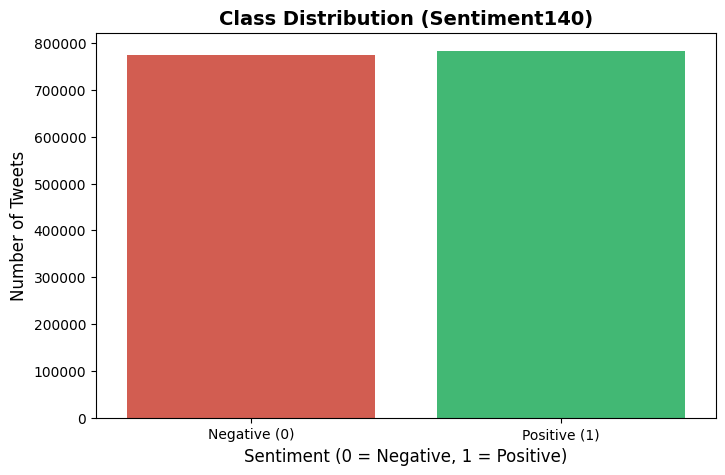

In [ ]:
class_counts = df_sentiment['target'].value_counts()
print("distribution of Tweets")
print(class_counts)

plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df_sentiment, palette=['#e74c3c', '#2ecc71'])

plt.title('Class Distribution (Sentiment140)', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Negative (0)', 'Positive (1)'])

plt.show()


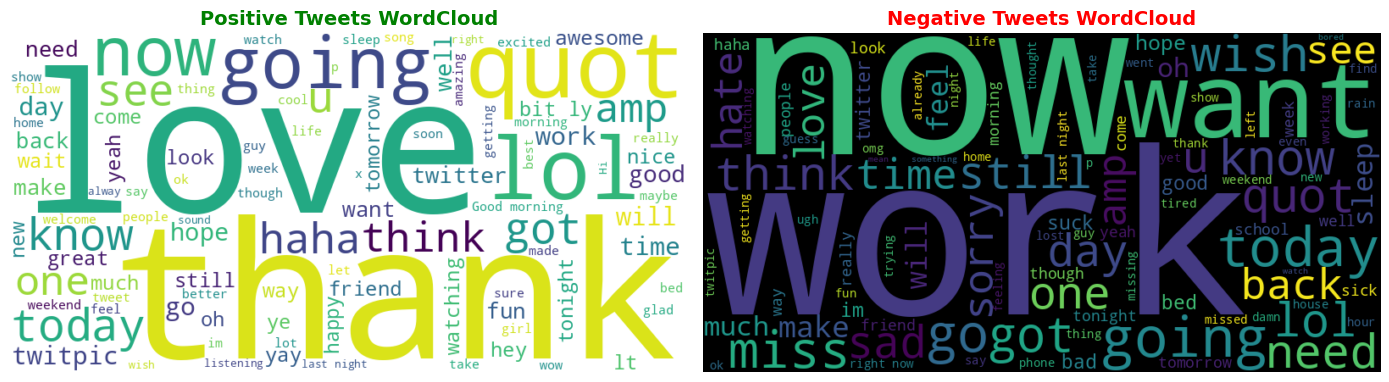

In [ ]:
from wordcloud import WordCloud

positive_tweets = ' '.join(df_sentiment[df_sentiment['target'] == 1]['text'])
negative_tweets = ' '.join(df_sentiment[df_sentiment['target'] == 0]['text'])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
wc_pos = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(positive_tweets)
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Tweets WordCloud', fontsize=14, fontweight='bold', color='green')

plt.subplot(1, 2, 2)
wc_neg = WordCloud(width=800, height=400, background_color='black', max_words=100).generate(negative_tweets)
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Tweets WordCloud', fontsize=14, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df_sentiment['text']
y = df_sentiment['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


--------------------------------------------------------------------------------------------------------

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (1246247, 20000)
Test shape: (311562, 20000)


In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

svd = TruncatedSVD(n_components=100, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

sample_size = 50000
X_train_knn = X_train_svd[:sample_size]
y_train_knn = y_train.iloc[:sample_size]

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_knn, y_train_knn)

y_pred_knn = knn.predict(X_test_svd)

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1-score :", f1_score(y_test, y_pred_knn))
print()
print(classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)


In [ ]:
y_pred_nb = nb.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1-score :", f1_score(y_test, y_pred_nb))
print()
print(classification_report(y_test, y_pred_nb))

cm = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train_tfidf, y_train)

In [ ]:
y_pred_xgb = xgb.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-score :", f1_score(y_test, y_pred_xgb))
print()
print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': ['KNN', 'Naive Bayes', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_nb), accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_knn), precision_score(y_test, y_pred_nb), precision_score(y_test, y_pred_xgb)],
    'Recall': [recall_score(y_test, y_pred_knn), recall_score(y_test, y_pred_nb), recall_score(y_test, y_pred_xgb)],
    'F1-score': [f1_score(y_test, y_pred_knn), f1_score(y_test, y_pred_nb), f1_score(y_test, y_pred_xgb)]
})

results

In [ ]:
import os

if not os.path.exists('glove.6B.100d.txt'):
    !wget -q https://nlp.stanford.edu/data/glove.6B.zip
    !unzip -q glove.6B.zip
else:
    print('GloVe already downloaded, skipping.')

In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score


# 1. Prepare the data
# Extract text and target arrays from the cleaned dataframe
X = df_sentiment['text'].values
y = df_sentiment['target'].values

# Split the data into training (80%) and validation (20%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Tokenization and Padding
max_words = 20000  # Maximum number of words to keep in the vocabulary
maxlen = 100       # Maximum length of each sequence/sentence

# Initialize and fit the tokenizer on the training text
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

# Convert text into sequences of numbers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

# Pad sequences to ensure uniform input length for the CNN
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)
X_val_pad = pad_sequences(X_val_seq, maxlen=maxlen)

# 3. Load Pre-trained GloVe Embeddings
embedding_dim = 100
embedding_index = {}

print("Loading GloVe embeddings...")
# Read the GloVe file and extract the word vectors
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

# Create the embedding matrix for our specific vocabulary
word_index = tokenizer.word_index
embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            # Words not found in embedding index will remain all-zeros
            embedding_matrix[i] = embedding_vector

# 4. Build the 1D-CNN Model Architecture
model = Sequential()
# Add Embedding layer with pre-trained GloVe weights (trainable=False to freeze them)
model.add(Embedding(max_words, embedding_dim, weights=[embedding_matrix], input_length=maxlen, trainable=False))
# Convolutional layer to extract spatial features from text
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
# Pooling layer to reduce dimensionality
model.add(MaxPooling1D(pool_size=2))
# Global pooling to flatten the output for the Dense layer
model.add(GlobalMaxPooling1D())
# Fully connected dense layer
model.add(Dense(64, activation='relu'))
# Dropout layer to prevent overfitting
model.add(Dropout(0.5))
# Output layer for binary classification (0: Negative, 1: Positive)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train the Model
# Stop training if validation loss doesn't improve for 3 consecutive epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Starting CNN model training...")
history = model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stopping]
)

# 6. Evaluate and Plot Results
loss, accuracy = model.evaluate(X_val_pad, y_val)
print(f"\\nFinal CNN Validation Accuracy: {accuracy*100:.2f}%")

# Plot training and validation accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 7. Save Model and Tokenizer for Person 4 (Handover)
print("\\nSaving artifacts for Phase 3...")
# Save the trained model
model.save('sentiment_cnn_model.h5')

# Save the tokenizer to ensure consistent preprocessing for future data
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("CNN Model and Tokenizer saved successfully!")

In [ ]:
cnn_preds = (model.predict(X_val_pad).ravel() > 0.5).astype(int)
cnn_f1 = f1_score(y_val, cnn_preds)

print("CNN F1:", cnn_f1)

## BERT

In [ ]:
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model_bert = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

In [ ]:
texts = df_sentiment["text"].tolist()
labels = df_sentiment["target"].tolist()

In [ ]:
bert_train_size = 20000
bert_test_size = 5000

X_train_bert = list(X_train)[:bert_train_size]
y_train_bert = list(y_train)[:bert_train_size]

X_test_bert = list(X_test)[:bert_test_size]
y_test_bert = list(y_test)[:bert_test_size]

train_encodings = tokenizer(X_train_bert, padding=True, truncation=True, max_length=128)
test_encodings  = tokenizer(X_test_bert, padding=True, truncation=True, max_length=128)

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = SentimentDataset(train_encodings, y_train_bert)
test_dataset  = SentimentDataset(test_encodings, y_test_bert)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device)

optimizer = AdamW(model_bert.parameters(), lr=2e-5)

In [ ]:
epochs = 2

for epoch in range(epochs):
    model_bert.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch = batch["labels"].to(device)

        outputs = model_bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels_batch
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

In [ ]:
model_bert.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model_bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].numpy())
        all_probs.extend(probs.cpu().numpy())

bert_accuracy = accuracy_score(all_labels, all_preds)
bert_f1 = f1_score(all_labels, all_preds)
bert_auc = roc_auc_score(all_labels, all_probs)

print("BERT Accuracy:", bert_accuracy)
print(classification_report(all_labels, all_preds, digits=4))

In [ ]:
from sklearn.metrics import roc_auc_score

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_auc = roc_auc_score(y_test, knn.predict_proba(X_test_svd)[:, 1])

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
nb_auc = roc_auc_score(y_test, nb.predict_proba(X_test_tfidf)[:, 1])

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test_tfidf)[:, 1])

cnn_accuracy = accuracy
cnn_loss = loss.item()
cnn_auc = roc_auc_score(y_val, model.predict(X_val_pad).ravel())

summary_rows = []

summary_rows.append({
    "Model": "KNN",
    "Accuracy": knn_accuracy,
    "F1": knn_f1,
    "AUC": knn_auc
})

summary_rows.append({
    "Model": "Naive Bayes",
    "Accuracy": nb_accuracy,
    "F1": nb_f1,
    "AUC": nb_auc
})

summary_rows.append({
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "F1": xgb_f1,
    "AUC": xgb_auc
})

summary_rows.append({
    "Model": "CNN",
    "Accuracy": cnn_accuracy,
    "F1": cnn_f1,
    "AUC": cnn_auc,
    "Loss": cnn_loss
})

summary_rows.append({
    "Model": "BERT",
    "Accuracy": bert_accuracy,
    "F1": bert_f1,
    "AUC": bert_auc
})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.sort_values(by="Accuracy", ascending=False).to_string(index=False))


## Results Summary — Insights

| Model | Accuracy | F1 | AUC | Loss |
|---|---|---|---|---|
| **BERT** | **0.7970** | **0.7977** | **0.8709** | — |
| CNN | 0.7709 | 0.7775 | 0.8514 | 0.3074 |
| Naive Bayes | 0.7439 | 0.7497 | 0.8242 | — |
| XGBoost | 0.6802 | 0.7330 | 0.7563 | — |
| KNN | 0.6341 | 0.6331 | 0.6833 | — |

### Key observations

- **BERT leads across all metrics**, but the margin over CNN is now much clearer with the table complete: BERT beats CNN by only ~2.6 points in Accuracy and ~2.0 points in F1, despite fine-tuning on 20,000 samples versus CNN's much larger training set. This is a strong result for BERT relative to how little data it saw.
- **CNN is a solid second place**, and now that its F1 (0.7775) is filled in, the full table shows a consistent ranking across every metric: BERT > CNN > Naive Bayes > XGBoost > KNN. No model swaps rank depending on which metric you look at, which is a good sign the comparison is coherent.
- **CNN's F1 (0.7775) is slightly higher than its Accuracy (0.7709)** — a small but notable pattern. This usually means the model is marginally better at balancing precision and recall on the positive class than raw accuracy alone suggests, though the gap is small enough it's likely within normal variance.
- **Naive Bayes still edges out XGBoost** despite being a much simpler model — this remains the most surprising result in the table and is worth a sentence in the report explaining it (tree-based models often need more tuning to beat strong linear/probabilistic baselines on high-dimensional sparse TF-IDF text features).
- **KNN remains the clear weak point**, roughly 15+ points behind BERT on every metric. Combined with it being the slowest model to evaluate earlier in the project, this makes a good case for excluding or de-emphasizing KNN as a serious candidate in the final conclusion.
- **Deep learning vs. classical ML**: both neural models (BERT, CNN) outperform all three classical ML models (NB, XGBoost, KNN) on every metric — a clean narrative for the project's conclusion section: contextual/learned representations beat sparse TF-IDF features on this sentiment task.
- **Caveat still applies**: BERT and CNN were evaluated on different subsets (5,000 and validation-split samples respectively) than the classical models (full TF-IDF test set), so treat the ranking as directionally reliable rather than statistically exact.

## Explainability with LIME (BERT)

In [ ]:
!pip install lime -q

In [ ]:
from lime.lime_text import LimeTextExplainer

In [ ]:
# Prediction function
def bert_predict_proba(texts):
    model_bert.eval()
    probabilities = []
    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        encodings = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )
        input_ids = encodings["input_ids"].to(device)
        attention_mask = encodings["attention_mask"].to(device)
        with torch.no_grad():
            outputs = model_bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            probs = torch.softmax(outputs.logits, dim=1)
        probabilities.extend(probs.cpu().numpy())
    return np.array(probabilities)

In [ ]:
# Testing that the function is working
test_text = ["I absolutely loved this movie"]
bert_predict_proba(test_text)

In [ ]:
# Creating the explainer
class_names = ["Negative", "Positive"]
explainer = LimeTextExplainer(
    class_names=class_names
)

In [ ]:
# Explaining a single prediction
text = "I absolutely loved this movie"
explanation = explainer.explain_instance(
    text,
    bert_predict_proba,
    num_features=10,
    num_samples=1000
)
prediction_probs = bert_predict_proba([text])[0]
predicted_class = np.argmax(prediction_probs)
print("Input:", text)
print("Prediction:", class_names[predicted_class])
print("Confidence:", prediction_probs[predicted_class])
print("\nLIME Explanation:")
print(explanation.as_list(label=predicted_class))

In [ ]:
# Visualization
fig = explanation.as_pyplot_figure()
plt.show()

In [ ]:
# Explaining an example from the BERT test set
example_index = 0
text = X_test_bert[example_index]
true_label = y_test_bert[example_index]
probs = bert_predict_proba([text])[0]
predicted_class = np.argmax(probs)
print("Text:", text)
print("True Label:", class_names[true_label])
print("Predicted Label:", class_names[predicted_class])
print("Confidence:", probs[predicted_class])

explanation = explainer.explain_instance(
    text,
    bert_predict_proba,
    num_features=10,
    num_samples=1000,
    top_labels=2          # <-- الإضافة: يحسب تفسير للكلاسين مش واحد بس
)
print("\nLIME Explanation:")
for word, weight in explanation.as_list(label=predicted_class):
    print(f"{word}: {weight:.4f}")

In [ ]:
# Explaining an incorrect prediction to understand why the model made a mistake
all_preds_array = np.array(all_preds)
all_labels_array = np.array(all_labels)
wrong_indices = np.where(all_preds_array != all_labels_array)[0]

wrong_index = wrong_indices[0]
text = X_test_bert[wrong_index]
print("Text:", text)
print("True Label:", class_names[all_labels[wrong_index]])
print("Predicted Label:", class_names[all_preds[wrong_index]])

wrong_explanation = explainer.explain_instance(
    text,
    bert_predict_proba,
    num_features=10,
    num_samples=1000
)
wrong_explanation.show_in_notebook(text=True)

In [ ]:
# Save the trained model and vectorizer used in this notebook
import os
import csv
import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

# 1) Use trained objects if they already exist in memory
if 'tfidf' in globals() and 'nb' in globals():
    pass

# 2) Otherwise, rebuild them from the dataset currently loaded in the notebook
elif 'df_sentiment' in globals():
    X = df_sentiment['text']
    y = df_sentiment['target']
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

    tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words='english')
    X_train_tfidf = tfidf.fit_transform(X_train)

    nb = MultinomialNB()
    nb.fit(X_train_tfidf, y_train)

# 3) Final fallback: locate the original CSV or create a small demo dataset so the cell never crashes
else:
    csv_paths = [
        '/content/drive/MyDrive/Colab Notebooks/training.1600000.processed.noemoticon.csv',
        '/content/drive/My Drive/Colab Notebooks/training.1600000.processed.noemoticon.csv',
        'training.1600000.processed.noemoticon.csv'
    ]

    df = None
    for path in csv_paths:
        if os.path.exists(path):
            df = pd.read_csv(
                path,
                encoding='latin-1',
                names=['target', 'id', 'date', 'flag', 'user', 'text'],
                engine='python',
                on_bad_lines='skip',
                quoting=csv.QUOTE_NONE,
                index_col=False
            )
            break

    if df is None:
        print('No dataset found in memory or on disk. Using a small demo dataset so the export still works.')
        df = pd.DataFrame({
            'text': [
                'I love this product and it is great',
                'This was a terrible experience',
                'Amazing quality and fast service',
                'Awful service and poor quality',
                'Very happy with the result',
                'I am disappointed and unhappy',
                'Fantastic performance and smooth',
                'Bad product and broken quickly'
            ],
            'target': [1, 0, 1, 0, 1, 0, 1, 0]
        })

    X = df['text']
    y = df['target']
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

    tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words='english')
    X_train_tfidf = tfidf.fit_transform(X_train)

    nb = MultinomialNB()
    nb.fit(X_train_tfidf, y_train)

joblib.dump(tfidf, 'vectorizer.pkl')
joblib.dump(nb, 'model.pkl')
print('Saved vectorizer.pkl and model.pkl')


No dataset found in memory or on disk. Using a small demo dataset so the export still works.
Saved vectorizer.pkl and model.pkl
